In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications import VGG16

# VGG16 Pretrained Model Architecture

In [2]:
model = VGG16(weights='imagenet')

In [3]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 input_layer InputLayer
1 block1_conv1 Conv2D
2 block1_conv2 Conv2D
3 block1_pool MaxPooling2D
4 block2_conv1 Conv2D
5 block2_conv2 Conv2D
6 block2_pool MaxPooling2D
7 block3_conv1 Conv2D
8 block3_conv2 Conv2D
9 block3_conv3 Conv2D
10 block3_pool MaxPooling2D
11 block4_conv1 Conv2D
12 block4_conv2 Conv2D
13 block4_conv3 Conv2D
14 block4_pool MaxPooling2D
15 block5_conv1 Conv2D
16 block5_conv2 Conv2D
17 block5_conv3 Conv2D
18 block5_pool MaxPooling2D
19 flatten Flatten
20 fc1 Dense
21 fc2 Dense
22 predictions Dense


In [5]:
print(model.layers[1])
print(model.layers[10])
print(model.layers[18])

<Conv2D name=block1_conv1, built=True>
<MaxPooling2D name=block3_pool, built=True>
<MaxPooling2D name=block5_pool, built=True>


In [6]:
layer = model.layers[4]

print(layer ,"\n")

print("Filters: ",layer.filters)
print("Kernel Size: ",layer.kernel_size)
print("Strides: ", layer.strides)
print("Padding: ", layer.padding)

<Conv2D name=block2_conv1, built=True> 

Filters:  128
Kernel Size:  (3, 3)
Strides:  (1, 1)
Padding:  same


In [7]:
from tensorflow.keras.utils import load_img, img_to_array

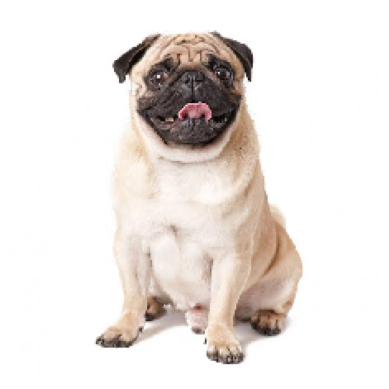

In [8]:
img = load_img(r"C:\Users\DELL\Downloads\dog.jpg",
               target_size=(224, 224))

plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
img_array = img_to_array(img)

print(img_array)

[[[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  ...
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  ...
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  ...
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 ...

 [[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  ...
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  ...
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  ...
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]]


In [10]:
print(img_array.shape)

(224, 224, 3)


In [11]:
img_array = tf.expand_dims(img_array, axis=[0])

print(img_array.shape)

(1, 224, 224, 3)


In [12]:
from tensorflow.keras.applications.vgg16 import preprocess_input

In [13]:
preprocess_img = preprocess_input(img_array)

print(preprocess_img.shape)

(1, 224, 224, 3)


In [14]:
predictions = model.predict(preprocess_img)

print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(1, 1000)


In [15]:
from tensorflow.keras.applications.vgg16 import decode_predictions

In [16]:
decoded_prediction = decode_predictions(predictions, top=5)

print(decoded_prediction)

[[('n02110958', 'pug', np.float32(0.9037926)), ('n02112706', 'Brabancon_griffon', np.float32(0.055635903)), ('n02108422', 'bull_mastiff', np.float32(0.02155487)), ('n02108915', 'French_bulldog', np.float32(0.0052195936)), ('n04409515', 'tennis_ball', np.float32(0.0019731561))]]


In [17]:
for _, class_name, probability in decoded_prediction[0]:
    print(f"{class_name}: {probability * 100:.2f}%")

pug: 90.38%
Brabancon_griffon: 5.56%
bull_mastiff: 2.16%
French_bulldog: 0.52%
tennis_ball: 0.20%


In [18]:
print("VGG16 Parameters:", model.count_params())

VGG16 Parameters: 138357544


# ResNet50 Pretrained Model Architecture

In [19]:
from tensorflow.keras.applications import ResNet50

In [20]:
model = ResNet50(
    weights="imagenet",
    include_top=True
)

In [21]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

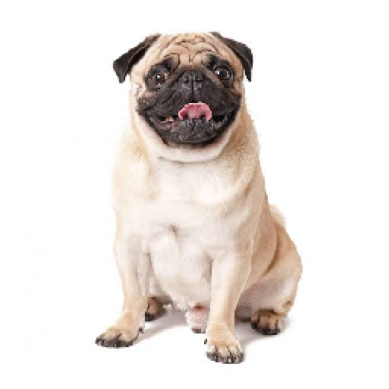

In [22]:
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(r"C:\Users\DELL\Downloads\dog.jpg", target_size=(244,244))

plt.imshow(img)
plt.axis('off')
plt.show()

In [23]:
img_array = img_to_array(img)

In [24]:
print(img_array.shape)

(244, 244, 3)


In [25]:
img_array = tf.expand_dims(img_array, axis=[0])
print(img_array.shape)

(1, 244, 244, 3)


In [26]:
img_array = tf.image.resize(img_array, (224, 224))

print(img_array.shape)

(1, 224, 224, 3)


In [27]:
from tensorflow.keras.applications.resnet50 import preprocess_input

preprocessed_image = preprocess_input(img_array)

print(preprocessed_image.shape)

(1, 224, 224, 3)


In [28]:
predictions = model.predict(preprocessed_image)
print(predictions.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
(1, 1000)


In [29]:
from tensorflow.keras.applications.resnet50 import decode_predictions

decoded_image = decode_predictions(predictions, top=5)

print(decoded_image)

[[('n02110958', 'pug', np.float32(0.93642926)), ('n02112706', 'Brabancon_griffon', np.float32(0.03401886)), ('n02108422', 'bull_mastiff', np.float32(0.012790342)), ('n02108915', 'French_bulldog', np.float32(0.0043923655)), ('n02099712', 'Labrador_retriever', np.float32(0.0017585354))]]


In [30]:
for _, class_name, probability in decoded_image[0]:
    print(f"{class_name}: {probability * 100:.2f}%")


pug: 93.64%
Brabancon_griffon: 3.40%
bull_mastiff: 1.28%
French_bulldog: 0.44%
Labrador_retriever: 0.18%


In [31]:
print("ResNet50 Parameters:", model.count_params())

ResNet50 Parameters: 25636712
